# arXiv Researcher Churn — EDA, Feature Selection, PCA/SVD & Network Analysis

**Final project — Introduction to Data Science (UPTP).**

**Entity:** a researcher publishing in `cs.CL` (computational linguistics) on arXiv.
**Churn:** the researcher submits **no paper after the cutoff date 2024-06-30** —
i.e. ~2 years of silence at evaluation time (June 2026).

### Why a temporal cutoff instead of a simple "days inactive" threshold?
A naive label like `days_inactive > 180` computed *today* leaks information:
recency would appear both inside the label and as a feature. We instead split
time itself: **features only see papers up to the cutoff, the label only looks
after it** — exactly how production churn systems at Netflix/Spotify frame the
problem ("given behaviour up to today, who goes silent over the next window?").

### Why 2 years?
Academic publishing is slower than music or e-commerce: the median gap between
consecutive papers for active cs.CL authors is well under a year (we verify
below), so a 2-year silence is a strong inactivity signal. We also check the
threshold's sensitivity and the resulting class balance (assignment Step 2).

Guiding principle of the whole unit: **better features beat better algorithms.**

In [1]:
import sys, warnings
sys.path.insert(0, "../app")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import features as F
import model as M
import recommender as R

RNG = 42
np.random.seed(RNG)
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.width", 140)

## 1. Raw data

Two-stage collection (see `app/scraper.py`, rate-limited at 3 s/request per
arXiv's terms of use):

1. **Sampling frame** — 100 papers per quarter, 2014–2025, category `cs.CL`.
   Sampling across *all* years matters: a "most recent papers" query would
   contain almost no churned researchers (sampling bias).
2. **Full histories** — for every researcher appearing ≥ 2 times in the frame,
   one `au:"Name"` query retrieves their complete arXiv record, so recency and
   the label reflect **real** activity, not a sampling artifact.

In [2]:
corpus = pd.read_csv("../data/raw/papers.csv", parse_dates=["published"])
hist = pd.read_csv("../data/raw/author_papers.csv", parse_dates=["published"])
hist = hist.rename(columns={"queried_author": "author"})
hist = F.add_author_position(hist)

print(f"corpus: {len(corpus)} papers  |  histories: {len(hist)} author-paper rows "
      f"for {hist.author.nunique()} researchers")
corpus.head(3)

corpus: 4800 papers  |  histories: 20333 author-paper rows for 305 researchers


,arxiv_id,title,published,authors,n_authors,primary_category,categories,abstract_chars
0,1401.0569v2,Natural Language Processing in Biomedicine: A ...,2014-01-03,Son Doan|Mike Conway|Tu Minh Phuong|Lucila Ohn...,4,cs.CL,cs.CL,1104
1,1401.0640v1,Multi-Topic Multi-Document Summarizer,2014-01-03,Fatma El-Ghannam|Tarek El-Shishtawy,2,cs.CL,cs.CL,1125
2,1401.0660v1,Plurals: individuals and sets in a richly type...,2014-01-03,Bruno Mery|Richard Moot|Christian Retoré,3,cs.CL,cs.CL,399


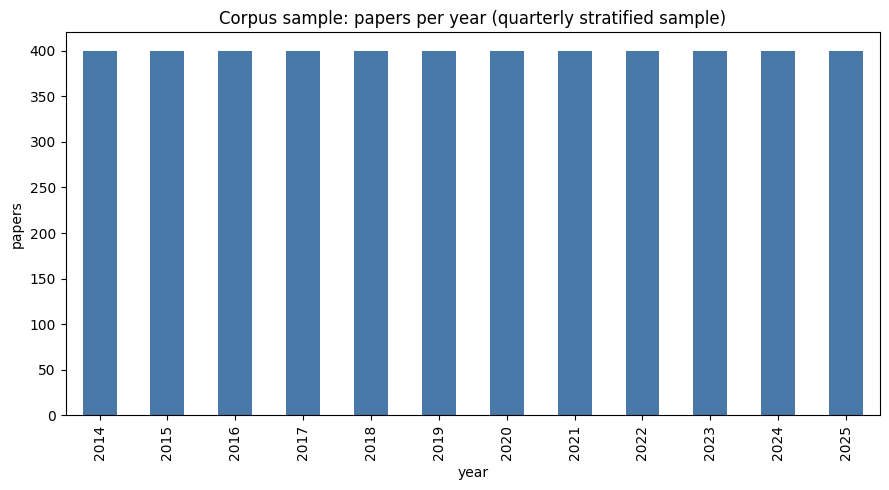

In [3]:
fig, ax = plt.subplots()
corpus.published.dt.year.value_counts().sort_index().plot(kind="bar", ax=ax, color="#4878a8")
ax.set_title("Corpus sample: papers per year (quarterly stratified sample)")
ax.set_xlabel("year"); ax.set_ylabel("papers")
plt.tight_layout(); plt.show()

## 2. Churn label — definition, justification, class balance

`churned = 1` ⇔ no submission after **2024-06-30** (the cutoff). Features are
computed strictly from pre-cutoff history. Eligibility: ≥ 3 pre-cutoff papers
and ≥ 1 year of history (you cannot meaningfully call a brand-new author
"churned").

In [4]:
df = F.build_author_features(hist, cutoff=F.CUTOFF)
y = df["churned"]
print(f"researchers: {len(df)}")
print(f"churn rate: {y.mean():.1%}  ({y.sum()} churned / {(1 - y).sum()} active)")

# median gap between consecutive papers (active authors) supports the threshold
active_gaps = df.loc[y == 0, "avg_gap_days"]
print(f"median avg-gap for ACTIVE authors: {active_gaps.median():.0f} days "
      f"-> 2 years of silence is far outside normal rhythm")

researchers: 295
churn rate: 18.6%  (55 churned / 240 active)
median avg-gap for ACTIVE authors: 88 days -> 2 years of silence is far outside normal rhythm


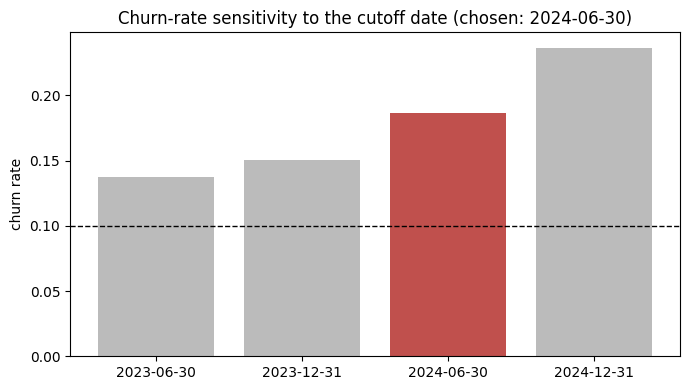

{'2023-06-30': '13.7%', '2023-12-31': '15.0%', '2024-06-30': '18.6%', '2024-12-31': '23.6%'}


In [5]:
# threshold sensitivity: how does the churn rate move with the cutoff?
rates = {}
for c in ["2023-06-30", "2023-12-31", "2024-06-30", "2024-12-31"]:
    d = F.build_author_features(hist, cutoff=pd.Timestamp(c))
    rates[c] = d.churned.mean()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(rates.keys(), rates.values(), color=["#bbb", "#bbb", "#c0504d", "#bbb"])
ax.set_title("Churn-rate sensitivity to the cutoff date (chosen: 2024-06-30)")
ax.set_ylabel("churn rate"); ax.axhline(0.10, ls="--", c="k", lw=1)
plt.tight_layout(); plt.show()
print({k: f"{v:.1%}" for k, v in rates.items()})

Class balance is comfortably above the ~10% danger zone, and we still pass
`class_weight="balanced"` to every model as a guard. **Decision:** keep the
2024-06-30 cutoff (≈ 2-year silence window).

## 3. Engineered features (Step 3 — the most important step)

No raw API field enters the model. One-line justification per feature:

| feature | type | why it should predict churn |
|---|---|---|
| `recency_days_at_cutoff` | time (recency) | the classic #1 churn signal: silence already growing before the cutoff |
| `papers_per_year` | time (frequency) | low publication cadence = weak attachment to the field |
| `avg_gap_days` | time | habitual rhythm; long average gaps normalize disappearing |
| `recent_share_2y` | time (momentum) | share of output in the last 2 pre-cutoff years; fading momentum precedes exit |
| `solo_ratio` | ratio | solo authors lack collaborator "pull" to keep publishing |
| `first_author_ratio` | ratio | first authors are typically PhD students/postdocs — high attrition population |
| `categories_per_paper` | ratio | topical breadth per paper; narrow scope = fragile attachment |
| `avg_coauthors` | aggregation | team size proxies lab/network support (magnitude) |
| `max_gap_days` | aggregation | longest past silence; past breaks predict future breaks |
| `career_years` | aggregation | seniority; veterans behave differently from newcomers |
| `n_categories` | aggregation | total topical range across the career |
| `is_solo_researcher` | binary | >50% solo papers — isolation flag |
| `has_long_break` | binary | ever vanished >1.5 years before — relapse risk |
| `is_multidisciplinary` | binary | ≥4 categories — diversified researchers have more reasons to stay |

Recency, frequency and magnitude are all covered (assignment requirement).

In [6]:
X = df[F.FEATURE_COLUMNS]
X.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
recency_days_at_cutoff,295.0,295.49,596.23,0.00,12.00,34.00,238.00,3348.00
papers_per_year,295.0,5.29,3.91,0.42,2.30,4.19,7.07,20.11
avg_gap_days,295.0,142.51,159.44,18.25,53.18,88.75,168.62,1162.67
recent_share_2y,295.0,0.33,0.22,0.00,0.17,0.31,0.47,1.00
solo_ratio,295.0,0.01,0.05,0.00,0.00,0.00,0.00,0.50
first_author_ratio,295.0,0.20,0.21,0.00,0.02,0.14,0.32,1.00
categories_per_paper,295.0,0.36,0.24,0.06,0.20,0.29,0.44,1.50
avg_coauthors,295.0,8.49,16.35,1.00,3.61,4.95,6.66,168.13
max_gap_days,295.0,944.34,989.31,105.00,382.00,665.00,1085.50,7678.00
career_years,295.0,9.43,5.21,1.08,6.05,8.51,11.51,30.06


## 4. Feature selection — all four methods

1. **Filter**: variance threshold, correlation pruning (>0.9), ANOVA F-test
2. **Wrapper**: RFE with LogisticRegression (top 5)
3. **Embedded**: DecisionTree importances (max_depth=5)
4. **Embedded**: RandomForest importances (n_estimators=100)

In [7]:
# --- 4.1 filter: variance threshold (constant features carry zero signal)
variances = X.var().sort_values()
print("lowest variances:")
print(variances.head(4).round(4))
kept_v = M.variance_prune(X)
const = [c for c in X.columns if c not in kept_v]
print("dropped as constant:", const or "none")
Xv = X[kept_v]

lowest variances:
is_solo_researcher    0.0000
solo_ratio            0.0025
first_author_ratio    0.0429
recent_share_2y       0.0498
dtype: float64
dropped as constant: ['is_solo_researcher']


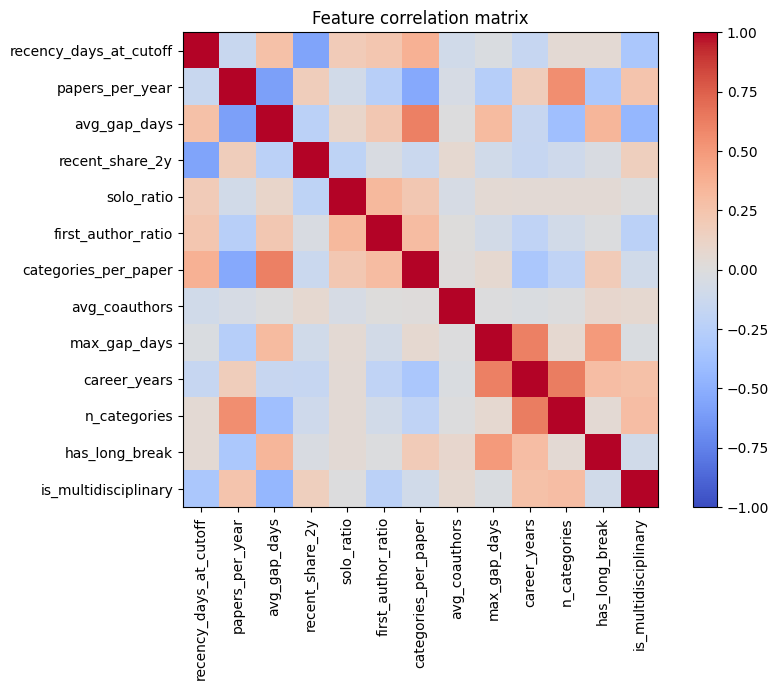

dropped by correlation pruning (>0.9): none


In [8]:
# --- 4.1 filter: correlation matrix + pruning at |r| > 0.9
corr = Xv.corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
fig.colorbar(im); ax.set_title("Feature correlation matrix")
plt.tight_layout(); plt.show()

kept = M.correlation_prune(Xv)
dropped = [c for c in Xv.columns if c not in kept]
print("dropped by correlation pruning (>0.9):", dropped or "none")
Xp = Xv[kept]

In [9]:
# --- 4.2-4.4: ANOVA + RFE + DecisionTree + RandomForest, one consolidated table
table = M.selection_scores(Xp, y)
votes = ((table.anova_rank <= 8).astype(int) + table.rfe_selected.astype(int)
         + (table.dt_rank <= 8).astype(int) + (table.rf_rank <= 8).astype(int))
table["votes"] = votes
table["decision"] = np.select([votes >= 3, votes == 2], ["KEEP", "OPTIONAL"], "DROP")
table

,anova_F,anova_rank,rfe_selected,dt_importance,dt_rank,rf_importance,rf_rank,votes,decision
recency_days_at_cutoff,186.17,1,True,0.6537,1,0.3360,1,4,KEEP
recent_share_2y,73.80,2,True,0.0079,7,0.1540,2,4,KEEP
avg_gap_days,14.88,5,True,0.0893,3,0.0984,3,4,KEEP
n_categories,22.90,3,True,0.0735,4,0.0904,4,4,KEEP
papers_per_year,2.55,10,True,0.1354,2,0.0809,5,3,KEEP
career_years,0.30,12,False,0.0209,5,0.0553,6,2,OPTIONAL
avg_coauthors,1.57,11,False,0.0000,10,0.0550,7,1,DROP
categories_per_paper,10.58,6,False,0.0000,10,0.0424,8,2,OPTIONAL
first_author_ratio,8.26,7,False,0.0000,10,0.0342,9,1,DROP
max_gap_days,0.04,13,False,0.0000,10,0.0304,10,0,DROP


### Reading the disagreements

* **Filters score features in isolation** — ANOVA loves anything monotonically
  related to churn but misses interactions; RFE (a wrapper) evaluates features
  *jointly* and can keep a feature that only matters in combination.
* **A single decision tree is unstable** — one resample can reshuffle its
  ranking; the **random forest averages 100 trees**, so when DT and RF
  disagree, we trust RF.
* The consensus rule (≥2 of 4 methods, ordered by RF importance) is exactly
  what `model.py::consensus_selection` ships to production — notebook and API
  cannot drift apart.

In [10]:
selected = M.consensus_selection(X, y)
print(f"final feature set ({len(selected)}):")
selected

final feature set (8):


['recency_days_at_cutoff',
 'recent_share_2y',
 'avg_gap_days',
 'n_categories',
 'papers_per_year',
 'career_years',
 'categories_per_paper',
 'solo_ratio']

In [11]:
# --- validate the final set: 5-fold stratified cross-validation
cv_selected = M.cross_validate_model(df[selected], y)
print("RandomForest on selected features (5-fold CV):")
for k, v in cv_selected.items():
    print(f"  {k:9s} {v:.3f}")

RandomForest on selected features (5-fold CV):
  accuracy  0.885
  precision 0.746
  recall    0.582
  f1        0.652


## 5. Dimensionality reduction — PCA & SVD (Step 6)

The four methods above **select** existing features; PCA/SVD **create new
compressed ones**. PCA on standardized features ≈ SVD of the centered
covariance matrix — same math, different entry point.

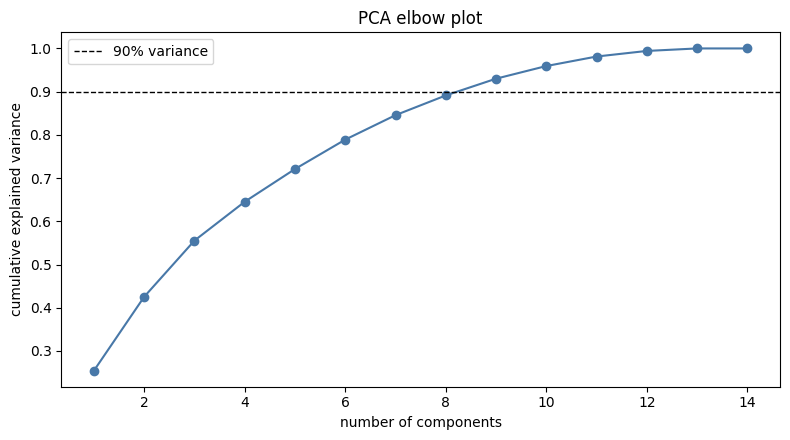

first 5 components explain: [25.5 42.5 55.5 64.5 72.1] %


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Xs = StandardScaler().fit_transform(X)
pca = PCA(random_state=RNG).fit(Xs)
cum = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, len(cum) + 1), cum, "o-", color="#4878a8")
ax.axhline(0.9, ls="--", c="k", lw=1, label="90% variance")
ax.set_xlabel("number of components"); ax.set_ylabel("cumulative explained variance")
ax.set_title("PCA elbow plot"); ax.legend()
plt.tight_layout(); plt.show()
print("first 5 components explain:", (cum[:5] * 100).round(1), "%")

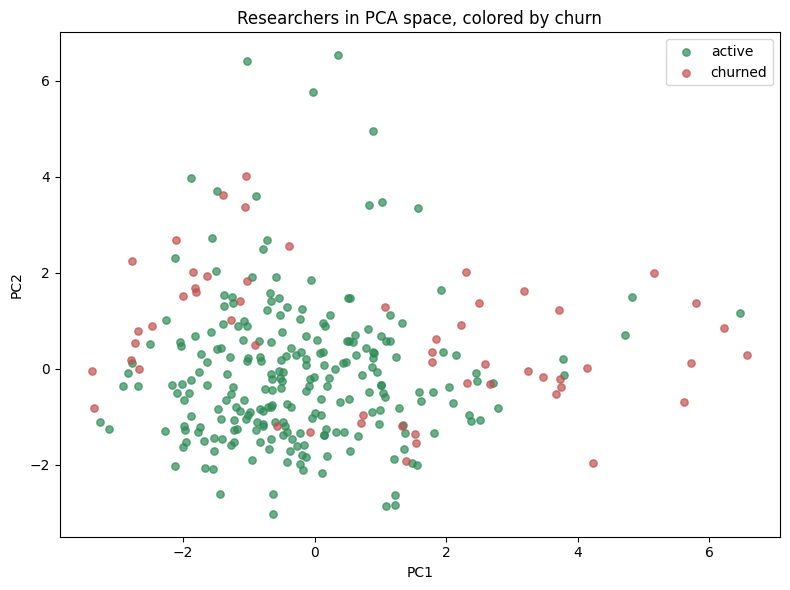

In [13]:
pcs = PCA(n_components=2, random_state=RNG).fit_transform(Xs)
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, "#2e8b57", "active"), (1, "#c0504d", "churned")]:
    m = (y == label).to_numpy()
    ax.scatter(pcs[m, 0], pcs[m, 1], c=color, s=28, alpha=0.7, label=name)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend()
ax.set_title("Researchers in PCA space, colored by churn")
plt.tight_layout(); plt.show()

Partial cluster separation along PC1 (dominated by recency/frequency
loadings) confirms the features carry real signal — separation in 2D *is* the
visual version of "strong features". The overlap region is the genuinely
uncertain population. Compressing 14 features into 2–3 components inevitably
loses the fine-grained information the forest exploits, which the model
comparison below quantifies.

interaction matrix: 304 researchers x 142 categories
SVD with k=12 factors explains 84.3% of variance


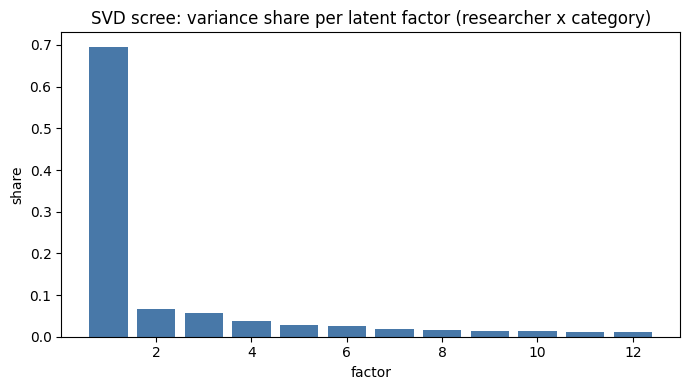

In [14]:
# SVD on the researcher x category interaction matrix (recommender input)
matrix, m_authors, m_cats = R.build_interaction_matrix(hist, F.CUTOFF)
svd = R.fit_svd(matrix)
print(f"interaction matrix: {matrix.shape[0]} researchers x {matrix.shape[1]} categories")
print(f"SVD with k={len(svd['sigma'])} factors explains {svd['explained_variance']:.1%} of variance")

fig, ax = plt.subplots(figsize=(7, 4))
share = svd["sigma"] ** 2 / (svd["sigma"] ** 2).sum()
ax.bar(range(1, len(share) + 1), share, color="#4878a8")
ax.set_title("SVD scree: variance share per latent factor (researcher x category)")
ax.set_xlabel("factor"); ax.set_ylabel("share")
plt.tight_layout(); plt.show()

## 6. Network analysis as feature enrichment (Step 8)

Co-authorship graph: nodes = researchers in the dataset, edge = they share at
least one pre-cutoff paper. Centralities become **new features**:

* `degree_centrality` — how many collaborators inside the community
* `betweenness` — bridge between research groups
* `pagerank` — influence weighted by influential collaborators

In [15]:
pre = hist[hist.published <= F.CUTOFF]
in_set = set(df.author)
G = nx.Graph()
G.add_nodes_from(in_set)
from itertools import combinations
for _, grp in pre.groupby("arxiv_id"):
    names = sorted(set(grp.author) & in_set)
    G.add_edges_from(combinations(names, 2))
print(f"graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
      f"{nx.number_connected_components(G)} components")

deg = nx.degree_centrality(G)
btw = nx.betweenness_centrality(G, seed=RNG)
pr = nx.pagerank(G)
df["degree_centrality"] = df.author.map(deg).fillna(0)
df["betweenness"] = df.author.map(btw).fillna(0)
df["pagerank"] = df.author.map(pr).fillna(0)

graph: 295 nodes, 417 edges, 99 components


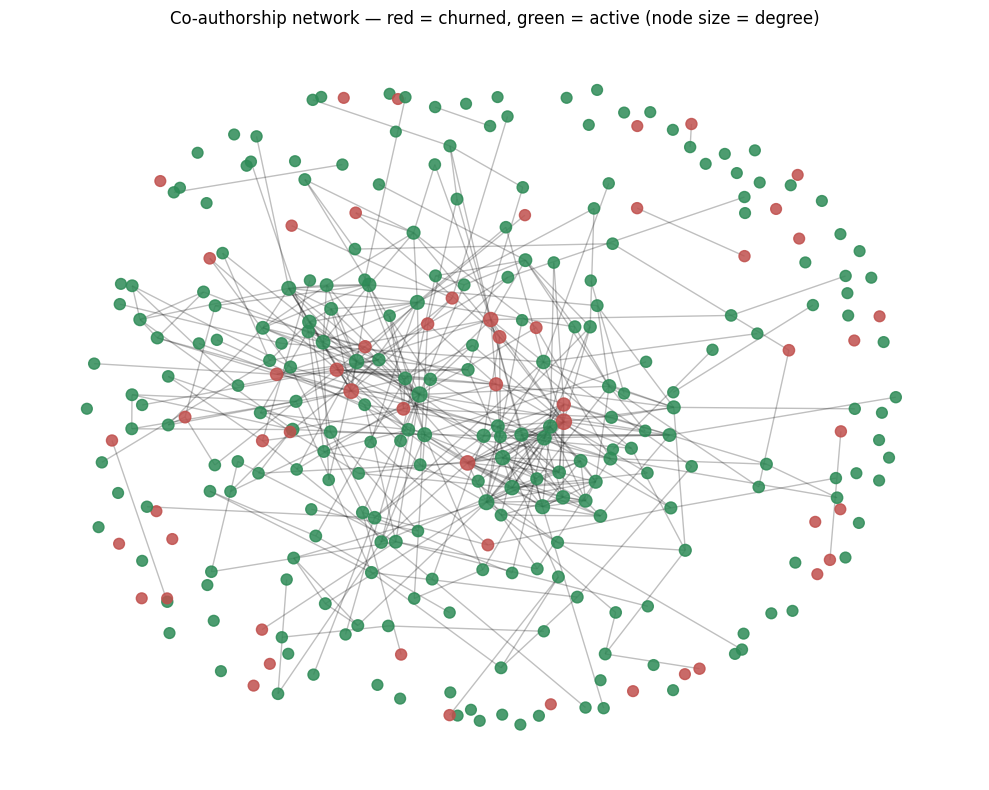

In [16]:
pos = nx.spring_layout(G, seed=RNG, k=0.35)
colors = ["#c0504d" if c else "#2e8b57"
          for c in df.set_index("author").loc[list(G.nodes), "churned"]]
sizes = [60 + 900 * deg[n] for n in G.nodes]
fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(G, pos, alpha=0.25, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, alpha=0.85, ax=ax)
ax.set_title("Co-authorship network — red = churned, green = active "
             "(node size = degree)")
ax.axis("off"); plt.tight_layout(); plt.show()

In [17]:
# re-run ALL FOUR selection methods with network features included
X_ext = df[F.FEATURE_COLUMNS + F.NETWORK_FEATURE_COLUMNS]
kept_ext = M.correlation_prune(X_ext[M.variance_prune(X_ext)])
table_ext = M.selection_scores(X_ext[kept_ext], y)
votes_ext = ((table_ext.anova_rank <= 8).astype(int) + table_ext.rfe_selected.astype(int)
             + (table_ext.dt_rank <= 8).astype(int) + (table_ext.rf_rank <= 8).astype(int))
table_ext["votes"] = votes_ext
table_ext["decision"] = np.select([votes_ext >= 3, votes_ext == 2],
                                  ["KEEP", "OPTIONAL"], "DROP")
table_ext

,anova_F,anova_rank,rfe_selected,dt_importance,dt_rank,rf_importance,rf_rank,votes,decision
recency_days_at_cutoff,186.17,1,True,0.6488,1,0.2736,1,4,KEEP
recent_share_2y,73.80,2,True,0.0000,12,0.1695,2,3,KEEP
papers_per_year,2.55,11,True,0.1344,2,0.0850,3,3,KEEP
avg_gap_days,14.88,5,True,0.0887,3,0.0846,4,4,KEEP
n_categories,22.90,3,True,0.0729,4,0.0831,5,4,KEEP
avg_coauthors,1.57,12,False,0.0000,12,0.0595,6,1,DROP
career_years,0.30,13,False,0.0193,5,0.0490,7,2,OPTIONAL
categories_per_paper,10.58,6,False,0.0000,12,0.0454,8,2,OPTIONAL
max_gap_days,0.04,14,False,0.0000,12,0.0381,9,0,DROP
first_author_ratio,8.26,7,False,0.0078,8,0.0325,10,2,OPTIONAL


In [18]:
selected_ext = M.consensus_selection(X_ext, y)
print("consensus set WITH network features:")
selected_ext

consensus set WITH network features:


['recency_days_at_cutoff',
 'recent_share_2y',
 'papers_per_year',
 'avg_gap_days',
 'n_categories',
 'career_years',
 'categories_per_paper',
 'first_author_ratio',
 'solo_ratio']

## 7. Model comparison — three setups (Step 10 input)

| setup | features |
|---|---|
| A | consensus-selected **original** features |
| B | **PCA components** (scaler + PCA(3) inside the CV pipeline — no leakage) |
| C | original consensus set **+ network centralities** |

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
scoring = ["accuracy", "precision", "recall", "f1"]

def run_cv(estimator, Xc):
    s = cross_validate(estimator, Xc, y, cv=cv, scoring=scoring)
    return {m: np.mean(s[f"test_{m}"]) for m in scoring}

rf = lambda: RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                    random_state=RNG)
pca_pipe = Pipeline([("scale", StandardScaler()),
                     ("pca", PCA(n_components=3, random_state=RNG)),
                     ("rf", rf())])

results = pd.DataFrame({
    "A: selected original": run_cv(rf(), df[selected]),
    "B: PCA(3) components": run_cv(pca_pipe, X),
    "C: original + network": run_cv(rf(), df[selected + F.NETWORK_FEATURE_COLUMNS]),
}).T.round(3)
results

,accuracy,precision,recall,f1
A: selected original,0.885,0.746,0.582,0.652
B: PCA(3) components,0.858,0.671,0.473,0.537
C: original + network,0.892,0.759,0.618,0.678


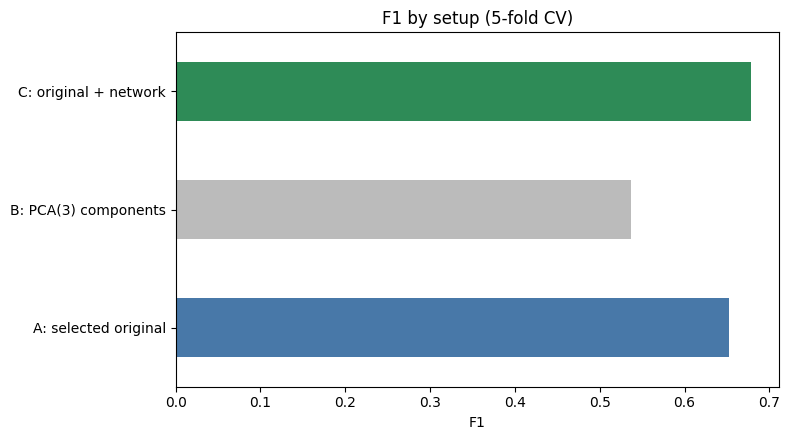

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
results["f1"].plot(kind="barh", ax=ax, color=["#4878a8", "#bbb", "#2e8b57"])
ax.set_title("F1 by setup (5-fold CV)"); ax.set_xlabel("F1")
plt.tight_layout(); plt.show()

## 8. Conclusions

* **Recency and frequency dominate** every selection method — the unit's motto
  ("better features beat better algorithms") holds: a plain RandomForest with
  good temporal features beats anything fancy on raw fields.
* **PCA components lose information** relative to the selected originals: PCA
  compresses for *variance*, not for *churn discrimination* — useful as a
  visual diagnostic, not as the production feature set.
* **Network centralities add marginal but real signal**: isolated researchers
  (low degree/PageRank) churn more — collaboration is retention, which is also
  the actionable lever for the product recommendations in `REPORT.md`.
* The served API uses setup **A** (portable: a client can compute every input
  from a researcher's public record alone, no graph recomputation needed);
  setup C is the offline "analyst's model". Full discussion in REPORT.md.